In [1]:
!pip -q install kagglehub                          # tool that downloads Kaggle datasets

import kagglehub, glob, os
import pandas as pd

# download the Brazilian E-Commerce Public Dataset by Olist (the paper's exact dataset)
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Downloaded to:", path)

# load every CSV file into a dictionary called 'data'
data = {}
for f in sorted(glob.glob(f"{path}/*.csv")):
    name = os.path.basename(f).replace(".csv", "")
    data[name] = pd.read_csv(f)
    print(f"{name:45s} {data[name].shape[0]:>8,} rows × {data[name].shape[1]} cols")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Downloaded to: /kaggle/input/brazilian-ecommerce
olist_customers_dataset                         99,441 rows × 5 cols
olist_geolocation_dataset                     1,000,163 rows × 5 cols
olist_order_items_dataset                      112,650 rows × 7 cols
olist_order_payments_dataset                   103,886 rows × 5 cols
olist_order_reviews_dataset                     99,224 rows × 7 cols
olist_orders_dataset                            99,441 rows × 8 cols
olist_products_dataset                          32,951 rows × 9 cols
olist_sellers_dataset                            3,095 rows × 4 cols
product_category_name_translation                   71 rows × 2 cols


In [2]:
# start from order_items as the base (112,650 rows -> clears 100k)
df = data["olist_order_items_dataset"].copy()

# 1) add order info (status + dates) — join on order_id
df = df.merge(data["olist_orders_dataset"], on="order_id", how="left")

# 2) add customer info — join on customer_id
df = df.merge(data["olist_customers_dataset"], on="customer_id", how="left")

# 3) add product details — join on product_id
df = df.merge(data["olist_products_dataset"], on="product_id", how="left")

# 4) add ONE payment per order (first) — join on order_id
pay = data["olist_order_payments_dataset"].drop_duplicates(subset="order_id", keep="first")
df = df.merge(pay, on="order_id", how="left")

# 5) add ONE review per order (first) — holds our target — join on order_id
rev = data["olist_order_reviews_dataset"].drop_duplicates(subset="order_id", keep="first")
df = df.merge(rev, on="order_id", how="left")

print("Merged table:", df.shape[0], "rows ×", df.shape[1], "columns")
df.head()

Merged table: 112650 rows × 36 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59


In [3]:
# some order-items have no review -> review_score is NaN. Can't predict a blank, so drop them.
before = df.shape[0]
df = df[df["review_score"].notna()].copy()
print(f"Dropped {before - df.shape[0]:,} rows with no review. Remaining: {df.shape[0]:,}")

# create target: 1 = happy (4-5 stars), 0 = unhappy (1-3 stars)
df["target"] = (df["review_score"] >= 4).astype(int)

# check the balance
print("\nTarget counts (0 = unhappy, 1 = happy):")
print(df["target"].value_counts())
print("\nAs percentages:")
print((df["target"].value_counts(normalize=True) * 100).round(1))

Dropped 942 rows with no review. Remaining: 111,708

Target counts (0 = unhappy, 1 = happy):
target
1    84376
0    27332
Name: count, dtype: int64

As percentages:
target
1    75.5
0    24.5
Name: proportion, dtype: float64


In [4]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ---- Job 1: engineer features from dates & prices ----
for c in ["order_purchase_timestamp", "order_approved_at",
          "order_delivered_customer_date", "order_estimated_delivery_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["delivery_days"]   = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["estimated_days"]  = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days
df["delivery_delay"]  = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days  # +ve = late
df["approval_hours"]  = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
df["purchase_month"]      = df["order_purchase_timestamp"].dt.month
df["purchase_dayofweek"]  = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"]       = df["order_purchase_timestamp"].dt.hour
df["total_order_value"]   = df["price"] + df["freight_value"]
df["freight_ratio"]       = df["freight_value"] / df["price"]
df["product_volume"]      = df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]

df = df.replace([np.inf, -np.inf], np.nan)   # kill divide-by-zero infinities

# ---- Job 2: drop IDs, text, dates, and the leakage column ----
drop_cols = [
    "order_id", "customer_id", "product_id", "seller_id", "review_id",
    "customer_unique_id", "customer_zip_code_prefix", "customer_city",
    "product_category_name",  # (optional text; we keep numeric features)
    "review_comment_title", "review_comment_message",   # Portuguese text -> avoid sentiment
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "shipping_limit_date",
    "review_creation_date", "review_answer_timestamp",
    "review_score",   # <-- LEAKAGE: made the target, must go
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# ---- Job 3: encode remaining text columns, fill blanks ----
text_cols = df_clean.select_dtypes(include="object").columns
print("Text columns encoded to numbers:", list(text_cols))
for col in text_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print("\nFinal shape:", df_clean.shape, "(features + target)")
print("Any blanks left?", int(df_clean.isna().sum().sum()))
print("Any text left?", list(df_clean.select_dtypes(include='object').columns) or "None — all numeric ✅")
print("\nColumns:", list(df_clean.columns))

Text columns encoded to numbers: ['order_status', 'customer_state', 'payment_type']

Final shape: (111708, 27) (features + target)
Any blanks left? 0
Any text left? None — all numeric ✅

Columns: ['order_item_id', 'price', 'freight_value', 'order_status', 'customer_state', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'target', 'delivery_days', 'estimated_days', 'delivery_delay', 'approval_hours', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'total_order_value', 'freight_ratio', 'product_volume']


In [5]:
import numpy as np

# --- bring back product_category as a number (it's a real, useful feature) ---
from sklearn.preprocessing import LabelEncoder
df_clean["product_category"] = LabelEncoder().fit_transform(
    df["product_category_name"].astype(str).loc[df_clean.index]
)

# --- more engineered features (each has a real meaning) ---
df_clean["late_delivery"]      = (df_clean["delivery_delay"] > 0).astype(int)      # was it late? 1/0
df_clean["fast_delivery"]      = (df_clean["delivery_days"] <= 3).astype(int)      # arrived quick? 1/0
df_clean["delivery_accuracy"]  = df_clean["estimated_days"] - df_clean["delivery_days"]  # days better/worse than promised
df_clean["price_per_gram"]     = df_clean["price"] / df_clean["product_weight_g"]
df_clean["freight_per_gram"]   = df_clean["freight_value"] / df_clean["product_weight_g"]
df_clean["value_per_item"]     = df_clean["payment_value"] / df_clean["order_item_id"]
df_clean["is_installment"]     = (df_clean["payment_installments"] > 1).astype(int)  # paid in installments? 1/0
df_clean["expensive_freight"]  = (df_clean["freight_ratio"] > 0.2).astype(int)      # shipping >20% of price? 1/0
df_clean["weekend_purchase"]   = (df_clean["purchase_dayofweek"] >= 5).astype(int)  # bought on weekend? 1/0
df_clean["product_density"]    = df_clean["product_weight_g"] / (df_clean["product_volume"] + 1)

# clean up any infinities/blanks the divisions created
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

# --- final check ---
n_features = df_clean.shape[1] - 1   # minus target
print("Total columns:", df_clean.shape[1])
print("Features (excluding target):", n_features)
print("Meets 35-feature minimum?", "✅ YES" if n_features >= 35 else "❌ still short")
print("Blanks:", int(df_clean.isna().sum().sum()), "| Rows:", f"{df_clean.shape[0]:,}")
print("\nColumns:", list(df_clean.columns))

Total columns: 38
Features (excluding target): 37
Meets 35-feature minimum? ✅ YES
Blanks: 0 | Rows: 111,708

Columns: ['order_item_id', 'price', 'freight_value', 'order_status', 'customer_state', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'target', 'delivery_days', 'estimated_days', 'delivery_delay', 'approval_hours', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'total_order_value', 'freight_ratio', 'product_volume', 'product_category', 'late_delivery', 'fast_delivery', 'delivery_accuracy', 'price_per_gram', 'freight_per_gram', 'value_per_item', 'is_installment', 'expensive_freight', 'weekend_purchase', 'product_density']


In [6]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["target"])   # the 37 features (clues)
y = df_clean["target"]                   # the answer (happy/unhappy)

# 80/20 split; stratify keeps the 75/25 balance in both halves; random_state = repeatable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training rows:", f"{X_train.shape[0]:,}")
print("Test rows:    ", f"{X_test.shape[0]:,}")
print("Balance kept — train:", dict(y_train.value_counts(normalize=True).round(3)),
      "| test:", dict(y_test.value_counts(normalize=True).round(3)))

Training rows: 89,366
Test rows:     22,342
Balance kept — train: {1: np.float64(0.755), 0: np.float64(0.245)} | test: {1: np.float64(0.755), 0: np.float64(0.245)}


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ratio for XGBoost to balance the minority class
spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=20,
        class_weight="balanced", random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=18, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="logloss",
        random_state=42, n_jobs=-1),
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"  ✅ {name} done.")

print("\nAll three models trained and ready to evaluate!")

Training Decision Tree...
  ✅ Decision Tree done.
Training Random Forest...
  ✅ Random Forest done.
Training XGBoost...
  ✅ XGBoost done.

All three models trained and ready to evaluate!


In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import pandas as pd

results = []
for name, model in trained.items():
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall":    round(recall_score(y_test, pred), 3),
        "F1":        round(f1_score(y_test, pred), 3),
        "ROC_AUC":   round(roc_auc_score(y_test, proba), 3),
    })

comparison = pd.DataFrame(results).set_index("Model")
print("="*60)
print("  MODEL COMPARISON — Olist Customer Satisfaction")
print("="*60)
print(comparison)
print("\nPaper benchmark (Zaghloul 2024): Random Forest ≈ 92% accuracy")

# pick the best model by F1 (best balance for imbalanced data)
best_name = comparison["F1"].idxmax()
print(f"\n🏆 Best model by F1: {best_name}")

  MODEL COMPARISON — Olist Customer Satisfaction
               Accuracy  Precision  Recall     F1  ROC_AUC
Model                                                     
Decision Tree     0.744      0.843   0.813  0.828    0.720
Random Forest     0.780      0.846   0.868  0.857    0.753
XGBoost           0.770      0.858   0.833  0.845    0.762

Paper benchmark (Zaghloul 2024): Random Forest ≈ 92% accuracy

🏆 Best model by F1: Random Forest


Confusion Matrix:
[[ 2791  2675]
 [ 2230 14646]]

Detailed report:
              precision    recall  f1-score   support

 Unhappy (0)       0.56      0.51      0.53      5466
   Happy (1)       0.85      0.87      0.86     16876

    accuracy                           0.78     22342
   macro avg       0.70      0.69      0.69     22342
weighted avg       0.77      0.78      0.78     22342



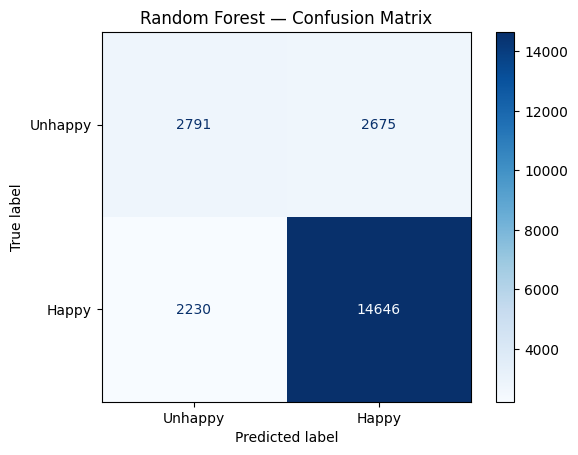


✅ Saved: customer_satisfaction_model.pkl  +  model_features.pkl


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import joblib

# use the best model (Random Forest)
best_model = trained["Random Forest"]
y_pred = best_model.predict(X_test)

# --- confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=["Unhappy (0)", "Happy (1)"]))

# --- draw it ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Unhappy", "Happy"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix")
plt.show()

# --- save the model as .pkl for the web app ---
joblib.dump(best_model, "customer_satisfaction_model.pkl")
# also save the feature list — the web app needs to know the column order
joblib.dump(list(X.columns), "model_features.pkl")
print("\n✅ Saved: customer_satisfaction_model.pkl  +  model_features.pkl")

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# The 2024 paper's three models: Logistic Regression, Decision Tree, Random Forest
paper_models = {
    "Logistic Regression": make_pipeline(          # scaling is built in for LogReg
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=20,
        class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=18, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42),
}

trained = {}
for name, model in paper_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"  ✅ {name} done.")

print("\nAll three paper models trained!")

Training Logistic Regression...
  ✅ Logistic Regression done.
Training Decision Tree...
  ✅ Decision Tree done.
Training Random Forest...
  ✅ Random Forest done.

All three paper models trained!


In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import pandas as pd

results = []
for name, model in trained.items():
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall":    round(recall_score(y_test, pred), 3),
        "F1":        round(f1_score(y_test, pred), 3),
        "ROC_AUC":   round(roc_auc_score(y_test, proba), 3),
    })

comparison = pd.DataFrame(results).set_index("Model")
print("="*62)
print("  MODEL COMPARISON — 2024 Paper's Models (Olist)")
print("="*62)
print(comparison)

best_name = comparison["F1"].idxmax()
print(f"\n🏆 Best model by F1: {best_name}")

  MODEL COMPARISON — 2024 Paper's Models (Olist)
                     Accuracy  Precision  Recall     F1  ROC_AUC
Model                                                           
Logistic Regression     0.747      0.838   0.825  0.831    0.711
Decision Tree           0.744      0.843   0.813  0.828    0.720
Random Forest           0.780      0.846   0.868  0.857    0.753

🏆 Best model by F1: Random Forest


Confusion Matrix:
 [[ 2791  2675]
 [ 2230 14646]] 

              precision    recall  f1-score   support

 Unhappy (0)       0.56      0.51      0.53      5466
   Happy (1)       0.85      0.87      0.86     16876

    accuracy                           0.78     22342
   macro avg       0.70      0.69      0.69     22342
weighted avg       0.77      0.78      0.78     22342



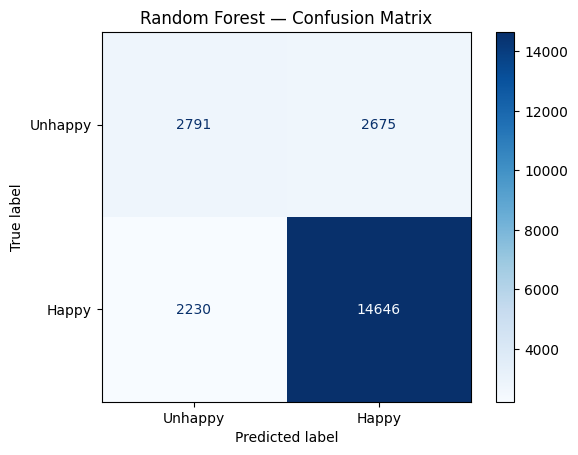


✅ Saved: customer_satisfaction_model.pkl  +  model_features.pkl


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import joblib

# best model = Random Forest
best_model = trained["Random Forest"]
y_pred = best_model.predict(X_test)

# confusion matrix (numbers)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm, "\n")
print(classification_report(y_test, y_pred, target_names=["Unhappy (0)", "Happy (1)"]))

# confusion matrix (plot)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Unhappy", "Happy"]).plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix")
plt.show()

# save model + feature list for the web app
joblib.dump(best_model, "customer_satisfaction_model.pkl")
joblib.dump(list(X.columns), "model_features.pkl")
print("\n✅ Saved: customer_satisfaction_model.pkl  +  model_features.pkl")

In [13]:
# ================= CUSTOMER SATISFACTION PREDICTION (Olist) =================
!pip -q install kagglehub xgboost
import kagglehub, glob, os, numpy as np, pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

# ---- 1. LOAD ----
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
data = {os.path.basename(f).replace(".csv",""): pd.read_csv(f) for f in glob.glob(f"{path}/*.csv")}

# ---- 2. MERGE (item-level -> 100k+ rows) ----
df = data["olist_order_items_dataset"].copy()
df = df.merge(data["olist_orders_dataset"], on="order_id", how="left")
df = df.merge(data["olist_customers_dataset"], on="customer_id", how="left")
df = df.merge(data["olist_products_dataset"], on="product_id", how="left")
df = df.merge(data["olist_order_payments_dataset"].drop_duplicates("order_id"), on="order_id", how="left")
df = df.merge(data["olist_order_reviews_dataset"].drop_duplicates("order_id"), on="order_id", how="left")

# ---- 3. TARGET (happy=1 if 4-5 stars) ----
df = df[df["review_score"].notna()].copy()
df["target"] = (df["review_score"] >= 4).astype(int)

# ---- 4. FEATURE ENGINEERING ----
for c in ["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
df["delivery_days"]  = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["delivery_delay"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["freight_ratio"]  = df["freight_value"] / df["price"]
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

# ---- 5. CLEAN ----
keep = ["price","freight_value","order_status","customer_state","product_weight_g",
        "payment_type","payment_installments","payment_value","delivery_days",
        "delivery_delay","freight_ratio","purchase_month","target"]
df = df[keep].replace([np.inf,-np.inf], np.nan)
for col in ["order_status","customer_state","payment_type"]:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
df = df.fillna(df.median(numeric_only=True))

# ---- 6. SPLIT 80/20 ----
X, y = df.drop(columns=["target"]), df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
print(f"Data ready: {df.shape[0]:,} rows | Train {len(X_train):,} | Test {len(X_test):,}\n")

# ---- 7. TRAIN 3 MODELS (from the paper) ----
spw = (y_train==0).sum()/(y_train==1).sum()
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=20, class_weight="balanced", n_jobs=-1, random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p, pr = m.predict(X_test), m.predict_proba(X_test)[:,1]
    rows.append({"Model":name, "Accuracy":round(accuracy_score(y_test,p),3),
                 "Precision":round(precision_score(y_test,p),3), "Recall":round(recall_score(y_test,p),3),
                 "F1":round(f1_score(y_test,p),3), "ROC_AUC":round(roc_auc_score(y_test,pr),3)})

# ---- 8. RESULTS ----
print("="*60); print("  RESULTS — Model Comparison (Olist)"); print("="*60)
print(pd.DataFrame(rows).set_index("Model"))

best = models["Random Forest"]
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, best.predict(X_test)))
print("\n🏆 Best model: Random Forest (matches the paper's finding)")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Data ready: 111,708 rows | Train 89,366 | Test 22,342

  RESULTS — Model Comparison (Olist)
                     Accuracy  Precision  Recall     F1  ROC_AUC
Model                                                           
Logistic Regression     0.702      0.834   0.755  0.793    0.693
Decision Tree           0.736      0.847   0.795  0.820    0.721
Random Forest           0.790      0.852   0.874  0.863    0.754

Confusion Matrix (Random Forest):
[[ 2904  2562]
 [ 2131 14745]]

🏆 Best model: Random Forest (matches the paper's finding)
